In [60]:
import mne
from mne.datasets import eegbci
import matplotlib.pyplot as plt

In [61]:
# 1. Define subject and run
# Runs 4, 8, 12 are "Imagined Left vs Right Fist"
"""
1
Baseline, eyes open
2
Baseline, eyes closed
3, 7, 11
Motor execution: left vs right hand
4, 8, 12
Motor imagery: left vs right hand
5, 9, 13
Motor execution: hands vs feet
6, 10, 14
Motor imagery: hands vs feet
"""
subject = 1
runs = [3]

In [62]:
# MAY REQUIRE SAYING YES TO USING THAT EXTERNAL DIRECTORY TO STORE THE DATA
# 2. Fetch the data (downloads to ~/mne_data by default)
raw_fnames = eegbci.load_data(subject, runs)
raw_filepath = raw_fnames[0]

In [63]:
# 3. Load the EDF file into memory
raw = mne.io.read_raw_edf(raw_filepath, preload=True)

Extracting EDF parameters from C:\Users\jason\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [64]:
# 4. Fix channel names to match the standard 10-10 layout
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage)

C:\Users\jason\AppData\Local\Temp\ipykernel_25616\3230595772.py:3: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [65]:
# 5. Extract task markers (annotations) into an event array
events, event_dict = mne.events_from_annotations(raw)

# Map the generic T0/T1/T2 tags to what they actually mean for this specific run
event_id = {'Rest (T0)': event_dict['T0'], 
            'Left_Fist (T1)': event_dict['T1'], 
            'Right_Fist (T2)': event_dict['T2']}

print(f"Events found: {event_id}")

Used Annotations descriptions: ['T0', 'T1', 'T2']
Events found: {'Rest (T0)': 1, 'Left_Fist (T1)': 2, 'Right_Fist (T2)': 3}


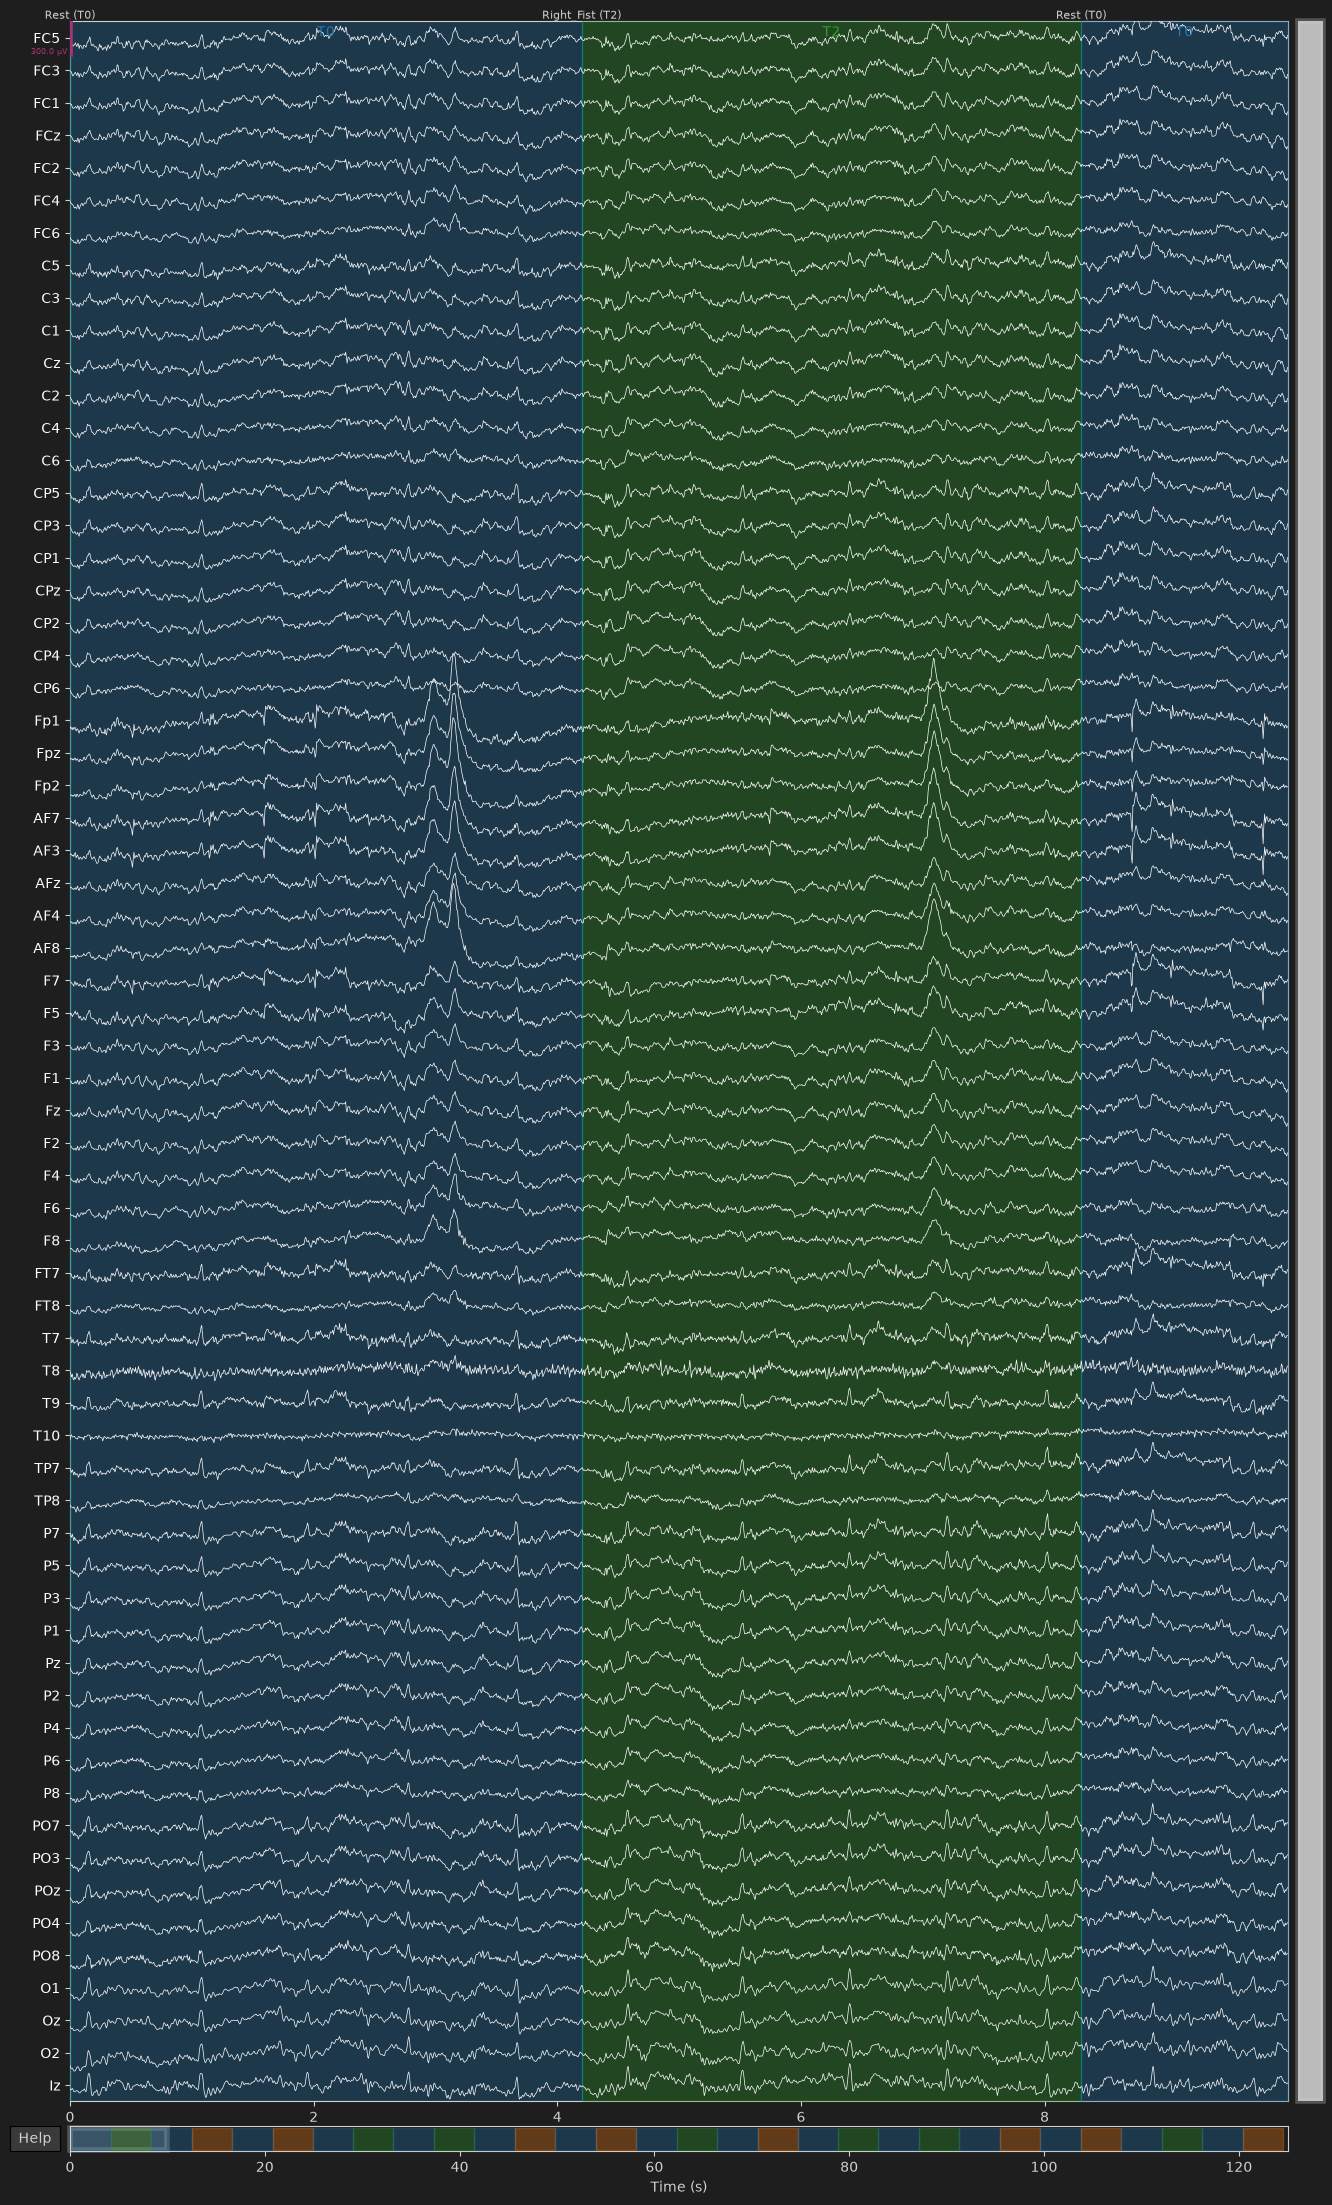

'\nY-Axis (Channels): Each horizontal line represents voltage from a specific electrode in the 10-10 system.\n\nFC indicates fronto-central, C indicates central (directly overlying the primary motor cortex), and CP indicates centro-parietal.\n\nOdd numbers (e.g., C3, C1) sit on the left hemisphere of the brain.\n\nEven numbers (e.g., C4, C2) sit on the right hemisphere.\n\nz denotes the midline (e.g., Cz).\n\n'

In [66]:
# 6. Visualize continuous data
# Note: If using VSCode Jupyter, add %matplotlib inline at the top of the cell

# there are 64 channels. n_channels = 64 
fig = raw.plot(
    events=events,
    event_id=event_id,
    n_channels=64,
    scalings=dict(eeg=150e-6),
    show=False
)
fig.set_size_inches(14, 24)

plt.show()

"""
Y-Axis (Channels): Each horizontal line represents voltage from a specific electrode in the 10-10 system.

FC indicates fronto-central, C indicates central (directly overlying the primary motor cortex), and CP indicates centro-parietal.

Odd numbers (e.g., C3, C1) sit on the left hemisphere of the brain.

Even numbers (e.g., C4, C2) sit on the right hemisphere.

z denotes the midline (e.g., Cz).

"""

In [67]:
# BANDPASS FILTER: MU AND BETA BANDS

import numpy as np

# 7. Isolate Mu (8-12 Hz) and Beta (16-24 Hz) frequency bands
raw_mu = raw.copy().filter(l_freq=8.0, h_freq=12.0, fir_design='firwin')
raw_beta = raw.copy().filter(l_freq=12.0, h_freq=24.0, fir_design='firwin')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 265 samples (1.656 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 12 - 24 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 12.00
- Lower transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 10.50 Hz)
- Upper passband edge:

In [68]:
# 8. Define epoch parameters centered around the task
tmin, tmax = 0.0, 4.0
trial_events = {'Left_Fist': event_dict['T1'], 'Right_Fist': event_dict['T2']}

epochs_params = dict(
    events=events, 
    event_id=trial_events, 
    tmin=tmin, 
    tmax=tmax, 
    baseline=None, 
    preload=True
)

In [69]:
# 9. Slice the filtered continuous streams into discrete trials
epochs_mu = mne.Epochs(raw_mu, **epochs_params)
epochs_beta = mne.Epochs(raw_beta, **epochs_params)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped


In [70]:
# 10. Extract time-series feature arrays
X_mu = epochs_mu.get_data(copy=False)      # Shape: (trials, 64 channels, 641 timepoints)
X_beta = epochs_beta.get_data(copy=False)
y = epochs_mu.events[:, -1]                # Target labels

print(f"Mu Feature Matrix: {X_mu.shape}")
print(f"Beta Feature Matrix: {X_beta.shape}")

Mu Feature Matrix: (15, 64, 641)
Beta Feature Matrix: (15, 64, 641)


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\jason\AppData\Local\Temp\ipykernel_25616\2434773389.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


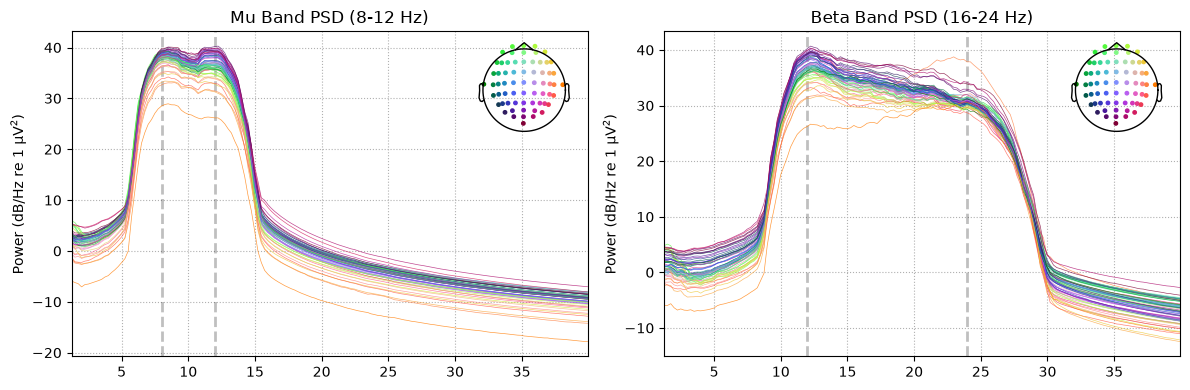

In [71]:
# 11. Visualize Power Spectral Density (PSD)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute and plot power across frequencies for the Mu epochs
epochs_mu.compute_psd(fmin=1, fmax=40).plot(axes=axes[0], show=False)
axes[0].set_title("Mu Band PSD (8-12 Hz)")

# Compute and plot power across frequencies for the Beta epochs
epochs_beta.compute_psd(fmin=1, fmax=40).plot(axes=axes[1], show=False)
axes[1].set_title("Beta Band PSD (16-24 Hz)")

plt.tight_layout()
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\jason\AppData\Local\Temp\ipykernel_25616\4054699596.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


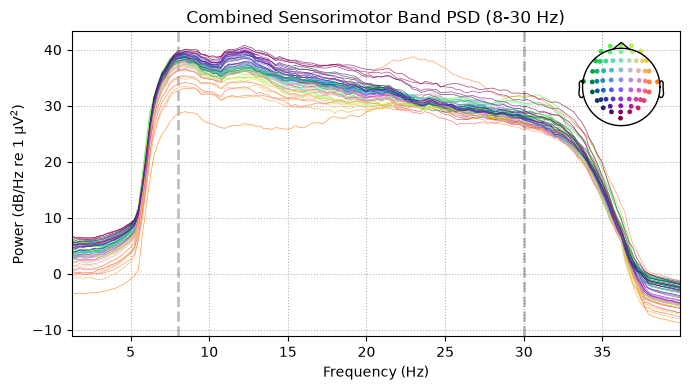

In [72]:
# Combined Sensorimotor Band (Mu + Beta: 8-30 Hz)
raw_smr = raw.copy().filter(l_freq=8.0, h_freq=30.0, fir_design='firwin')

epochs_smr = mne.Epochs(raw_smr, **epochs_params)
X_smr = epochs_smr.get_data(copy=False)  # Shape: (trials, 64 channels, 641 timepoints)

# Quick PSD verification
fig, ax = plt.subplots(figsize=(7, 4))
epochs_smr.compute_psd(fmin=1, fmax=40).plot(axes=ax, show=False)
ax.set_title("Combined Sensorimotor Band PSD (8-30 Hz)")
plt.tight_layout()
plt.show()